In [1]:
#Set up paths
import sys
import os

from Utils import utils as uti

from Utils import GridUtils as GrU
from Utils import MakePressures as MkP


import regrid_wavecube as rwv


# The usual
from datetime import date
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.tri as tri

# Cartopy for pretty maps
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Some other useful packages 
import importlib
import copy
import time
import cftime
import yaml
import glob
#from box import Box #???

importlib.reload( rwv )
importlib.reload(MkP)
importlib.reload(GrU)


 Utils.MyConstants in /glade/work/juliob/HiRes_ana_dev/Drivers/Utils 
Using Flexible parallel/serial VertRegrid 
 Utils.MyConstants in /glade/work/juliob/HiRes_ana_dev/Drivers/Utils 


<module 'Utils.GridUtils' from '/glade/work/juliob/HiRes_ana_dev/Drivers/Utils/GridUtils.py'>

In [2]:
import glob
import os

pattern = '/glade/derecho/scratch/juliob/archive//c153_topfix_ne240pg3_FMTHIST_xic_x02/atm/WaveCube/c153_topfix_ne240pg3_FMTHIST_xic_x02.cam.h1i.2004-07-*.nc'
files = sorted(glob.glob(pattern))

print(f"Found {len(files)} files")



Found 124 files


In [3]:
#print( files )
X=xr.open_dataset( files[0] )
print( X.sizes['lat'] )
print( X.lat[300].values )
nt,nz,ny,nx= len(files),X.sizes['lev'],X.sizes['lat'],X.sizes['lon'] 
print( nt,nz,ny,nx )
wp_tyx=np.zeros( (nt,ny,nx ) )
wp_tzx=np.zeros( (nt,nz,nx ) )

tbk_tzx = np.zeros( (nt,nz,nx ) )
ubk_tzx = np.zeros( (nt,nz,nx ) )


1440
-52.4375
124 93 1440 2880


In [5]:
n=0
for f in files:
    X=xr.open_mfdataset(f , data_vars='different', coords='different' , compat='no_conflicts' )
    wp_ =X.wp.isel(lev=20).values
    wp_tyx[n,:,:] = wp_
    wp_ =X.wp.sel(lat=-52.4,method='nearest').values
    wp_tzx[n,:,:] = wp_

    a_ =X.Tbk.sel(lat=-52.4,method='nearest').values
    tbk_tzx[n,:,:] = a_

    a_ =X.Ubk.sel(lat=-52.4,method='nearest').values
    ubk_tzx[n,:,:] = a_

    n=n+1
    if (n%10==0):
        print( f )

/glade/derecho/scratch/juliob/archive//c153_topfix_ne240pg3_FMTHIST_xic_x02/atm/WaveCube/c153_topfix_ne240pg3_FMTHIST_xic_x02.cam.h1i.2004-07-03-21600.nc
/glade/derecho/scratch/juliob/archive//c153_topfix_ne240pg3_FMTHIST_xic_x02/atm/WaveCube/c153_topfix_ne240pg3_FMTHIST_xic_x02.cam.h1i.2004-07-05-64800.nc
/glade/derecho/scratch/juliob/archive//c153_topfix_ne240pg3_FMTHIST_xic_x02/atm/WaveCube/c153_topfix_ne240pg3_FMTHIST_xic_x02.cam.h1i.2004-07-08-21600.nc
/glade/derecho/scratch/juliob/archive//c153_topfix_ne240pg3_FMTHIST_xic_x02/atm/WaveCube/c153_topfix_ne240pg3_FMTHIST_xic_x02.cam.h1i.2004-07-10-64800.nc
/glade/derecho/scratch/juliob/archive//c153_topfix_ne240pg3_FMTHIST_xic_x02/atm/WaveCube/c153_topfix_ne240pg3_FMTHIST_xic_x02.cam.h1i.2004-07-13-21600.nc
/glade/derecho/scratch/juliob/archive//c153_topfix_ne240pg3_FMTHIST_xic_x02/atm/WaveCube/c153_topfix_ne240pg3_FMTHIST_xic_x02.cam.h1i.2004-07-15-64800.nc
/glade/derecho/scratch/juliob/archive//c153_topfix_ne240pg3_FMTHIST_xic_x02/

In [7]:

plev=X.lev.values
lon=X.lon.values
zlev= -7_000.*np.log( plev/1000. )
print( zlev[10] )

43894.71084178742


In [ ]:
fig,ax=plt.subplots( 1,1 , figsize=(40,6) )
c=ax.contourf( lon,zlev,wp_tzx[13,:,:] , cmap='bwr' )
plt.colorbar( c )

In [8]:
from Regridder import VertRegridFlexLL as vrg

#zSrc=np.zeros( (nt,nz,nx ) )

nz_m=128
zlev_m = np.linspace( 0., zlev[0], num=nz_m )

zSrc = zlev[None, :, None]
zSrc = np.broadcast_to(zlev[None, :, None], (nt, nz, nx))
zDst = zlev_m[None, :, None]
zDst = np.broadcast_to(zlev_m[None, :, None], (nt, nz_m, nx))

#plt.contourf( zSrc[15,:,:] )
#plt.colorbar()

wp_tzx_m = vrg.VertRG( a_x=wp_tzx , zSrc=zSrc, zDst=zDst, Gridkey='tzc' , fill_value='extrapolate', kind='linear' )
ubk_tzx_m = vrg.VertRG( a_x=ubk_tzx , zSrc=zSrc, zDst=zDst, Gridkey='tzc' , fill_value='extrapolate', kind='linear' )
tbk_tzx_m = vrg.VertRG( a_x=tbk_tzx , zSrc=zSrc, zDst=zDst, Gridkey='tzc' , fill_value='extrapolate', kind='linear' )




Flexible VertRegrid using reshaped ARRAYS 
nworkers available  1
Using serial code which is faster for 1 worker
Pll'zd Vertical int 8.1536 seconds
Flexible VertRegrid using reshaped ARRAYS 
nworkers available  1
Using serial code which is faster for 1 worker
Pll'zd Vertical int 8.1969 seconds
Flexible VertRegrid using reshaped ARRAYS 
nworkers available  1
Using serial code which is faster for 1 worker
Pll'zd Vertical int 7.9923 seconds


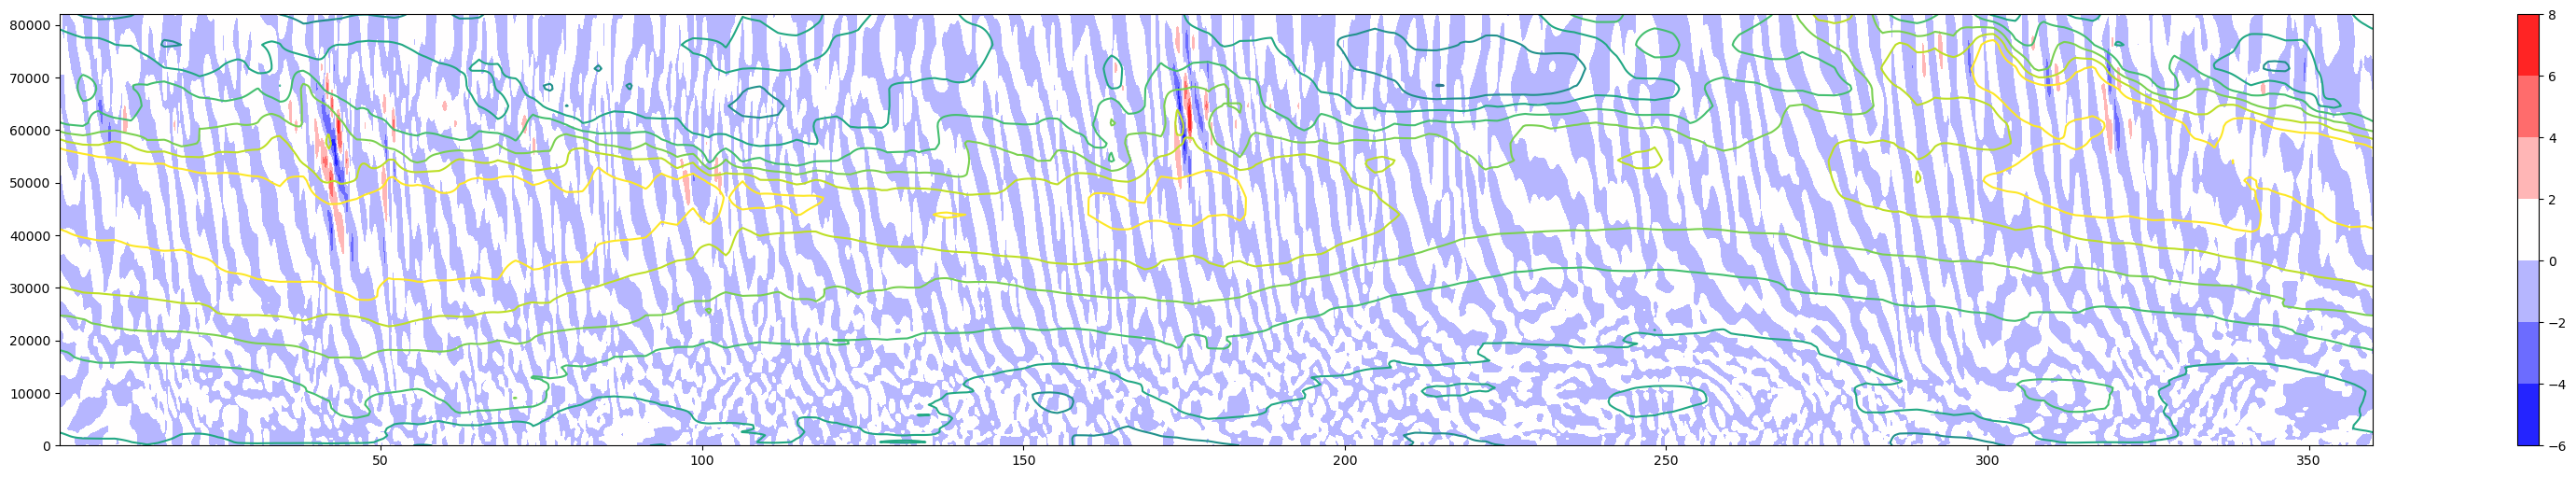

In [10]:
fig,ax=plt.subplots( 1,1 , figsize=(40,6) )
c=ax.contourf( lon,zlev_m,wp_tzx_m[13,:,:] , cmap='bwr' )
l=ax.contour( lon,zlev_m,ubk_tzx_m[13,:,:] , levels=np.linspace(-100.,100., 11 ) )

plt.colorbar( c )

In [ ]:
plt.contourf( wp52S[:,10,:] )

In [ ]:
print( files[56] )


In [ ]:
%%time
f=files[56]
Xt=xr.open_mfdataset(f , data_vars='different', coords='different' , compat='no_conflicts' )

In [ ]:
ub=Xt.Ubk.values
up=Xt.up.values

vb=Xt.Vbk.values
vp=Xt.vp.values

wb=Xt.Wbk.values
wp=Xt.wp.values

tb=Xt.Tbk.values
tp=Xt.tp.values



In [ ]:
fig,axs = plt.subplots( 1, 4, figsize=(20,4) )

x,y = 300,300

p=0
ax=axs[p]
ax.plot( ub[0,:,y,x]  , zlev )
ax.plot( (ub+up)[0,:,y,x]  , zlev, '-.' )

p=1
ax=axs[p]
ax.plot( vb[0,:,y,x]  , zlev )
ax.plot( (vb+vp)[0,:,y,x]  , zlev, '-.' )

p=2
ax=axs[p]
ax.plot( wb[0,:,y,x]  , zlev )
ax.plot( (wb+wp)[0,:,y,x]  , zlev, '-.' )

p=3
ax=axs[p]
ax.plot( tb[0,:,y,x]  , zlev )
ax.plot( (tb+tp)[0,:,y,x]  , zlev, '-.' )





In [ ]:
x0,x1=200,400
y0,y1=250,350
up_cube=up[0,:, y0:y1 , x0:x1]  #    250:350,200:400]
wp_cube=wp[0,:, y0:y1 , x0:x1]  #    250:350,200:400]


In [ ]:
plt.contourf( lon[200:400] ,zlev,wp_cube[:,50,:] )

In [ ]:
ps=X.PS.values
psb=X.PSbk.values


In [ ]:
plt.contourf(ps[0,:,:] )
plt.colorbar()